# WASP2026 draft: mean colour value

A single panel, for one question: **what is the mean value of the data along
the colour-axis**. It is the figure this notebook used to build from the
`jcdl_followup` run -- the one marked "THIS ONE BELOW IS THE ONE WE USE IN THE
PAPER" -- reduced to one question and repointed at this project. That code has
been removed; it is in git history if it is ever wanted back.

* one stepped histogram per low-tier model, as in the paper figure
* x-axis is **sSMAPE**, the signed symmetric percentage error used there:

      sSMAPE = (LMM - GT) / ((|LMM| + |GT|) / 2)

  It is bounded on [-2, 2]: 0 is exact, negative means the model
  under-estimated, +/-2 means it was wrong by more than the scale of the answer
  (or got the sign wrong).  Bounded is the point -- the colour values span many
  orders of magnitude across figures, so a plain relative error would be
  unplottable.

Self-contained: no `parse_lmm_output_utils` / `results_plotting_utils`, which
are not part of this repo.


In [1]:
# ======================== CONFIG ========================
#run_dir      = '~/Dropbox/WASP2026/LMM_outputs_tests2/'   # stand-in for the full run
run_dir      = '~/Dropbox/WASP2026/LMM_outputs_n150/'   # stand-in for the full run


qa_jsons_dir = '~/Dropbox/WASP2026/VQA/qa_jsons/'
fig_out_dir  = '~/Dropbox/WASP2026/paper_figures/'
fig_name     = 'mean_color_ssmape.pdf'

# model subdirectory -> (display name, colour).  Colours are the low-tier ones
# from the paper figure.
model_spec = {
    'chatgpt_api':  ('GPT',    'darkblue'),
    'gemini':       ('Gemini', 'orange'),
    'claude_haiku': ('Claude', 'cyan'),
}

# which question, matched on the rendered question text
question_match = ('mean value', 'color-axis')
question_label = r'$\mathrm{\langle data_{color} \rangle}$'

# restrict to one figure category, or None to pool all three
# ('contour', 'sky-gmm', 'sky-real')
only_category = None

# histogram / axes -- same look as the paper figure
# The paper used 40 bins, which needs a few hundred points per model to look
# like a distribution.  On the 15-figure stand-in run each bar is one figure, so
# this is dialled down; put it back to 40 for the full run.
nbins      = 17
xlim       = (-2.05, 2.05)
ylim       = None          # None -> autoscale
hist_thick = 3
show_zero_line = True      # mark the exact answer


In [2]:
import os, json, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_dir      = os.path.expanduser(run_dir)
qa_jsons_dir = os.path.expanduser(qa_jsons_dir)
fig_out_dir  = os.path.expanduser(fig_out_dir)
os.makedirs(fig_out_dir, exist_ok=True)


def json_objects(s):
    """Every top-level JSON object in `s`, in order, using the real decoder."""
    if not isinstance(s, str):
        return []
    dec, out, i = json.JSONDecoder(), [], 0
    while True:
        i = s.find('{', i)
        if i < 0:
            break
        try:
            obj, end = dec.raw_decode(s, i)
        except ValueError:
            i += 1
            continue
        if isinstance(obj, dict):
            out.append(obj)
        i = end
    return out


def recovered_answer(entry):
    """
    The model's answer.  `entry['Response']` is usually the explanation alone --
    the models emit answer and explanation as two separate json blocks and
    parse_qa keeps only the last -- so the answer is rebuilt from `raw answer`.
    The first non-explanation key is it, whatever the model named it
    ("mean_color", "mean color", ...).
    """
    merged = {}
    for o in json_objects(entry.get('raw answer')):
        merged.update(o)
    resp = entry.get('Response')
    if isinstance(resp, dict):
        for k, v in resp.items():
            merged.setdefault(k, v)
    for k, v in merged.items():
        if k.lower().strip() != 'explanation':
            return v
    return None


def as_float(x):
    """A single float out of a bare value, a nested dict, or a one-item list."""
    while isinstance(x, dict) and x:
        x = list(x.values())[0]
    if isinstance(x, (list, tuple)):
        x = x[0] if x else None
    if isinstance(x, str):
        x = x.replace(',', '').strip()
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan


_cat_cache = {}

def figure_category(vqa_id):
    """contour / sky-gmm / sky-real, from the figure's own data."""
    if vqa_id not in _cat_cache:
        with open(os.path.join(qa_jsons_dir, vqa_id + '_qa.json')) as f:
            d = json.loads(json.load(f))
        p = d['plot0']
        _cat_cache[vqa_id] = ('contour' if p['type'] == 'contour'
                              else 'sky-gmm' if p.get('distribution') == 'gmm'
                              else 'sky-real')
    return _cat_cache[vqa_id]


def ssmape(lmm, gt):
    """Signed symmetric percentage error, bounded on [-2, 2]."""
    denom = (np.abs(lmm) + np.abs(gt)) / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(denom > 0, (lmm - gt) / denom, np.nan)


In [3]:
# ======================== PARSE ========================
rows = []
for mdir, (mname, _) in model_spec.items():
    pkls = sorted(glob.glob(os.path.join(run_dir, mdir, '*_qa.pickle')))
    if not pkls:
        print('[WARN] no pickles in', os.path.join(run_dir, mdir))
        continue
    for fp in pkls:
        vqa_id = os.path.basename(fp).removesuffix('_qa.pickle')
        with open(fp, 'rb') as f:
            payload = pickle.load(f)
        qa_list = payload[0] if isinstance(payload, (list, tuple)) else payload
        for e in qa_list:
            q = (e.get('question') or '').lower()
            if not all(m in q for m in question_match):
                continue
            rows.append({'model': mname, 'vqa_id': vqa_id,
                         'category': figure_category(vqa_id),
                         'GT': as_float(e.get('A')),
                         'LMM': as_float(recovered_answer(e))})

dfmean = pd.DataFrame(rows)
if only_category is not None:
    dfmean = dfmean[dfmean['category'] == only_category]
dfmean['sSMAPE'] = ssmape(dfmean['LMM'].values, dfmean['GT'].values)

print('%d answers, %d figures, categories %s'
      % (len(dfmean), dfmean['vqa_id'].nunique(),
         dfmean['category'].value_counts().to_dict()))
print()
print('unparseable LMM answers (counted, then dropped from the histogram):')
print(dfmean[dfmean['LMM'].isna()].groupby('model').size().to_string() or '  none')
print()
print(dfmean.groupby('model')['sSMAPE']
      .describe()[['count', 'mean', '50%', 'min', 'max']].round(3).to_string())


450 answers, 150 figures, categories {'sky-gmm': 150, 'contour': 150, 'sky-real': 150}

unparseable LMM answers (counted, then dropped from the histogram):
model
Claude     1
GPT       22
Gemini     1

        count   mean    50%  min  max
model                                
Claude  148.0  0.613  0.544 -2.0  2.0
GPT     127.0  0.382  0.455 -2.0  2.0
Gemini  148.0  0.561  0.424 -2.0  2.0


wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/mean_color_ssmape.pdf


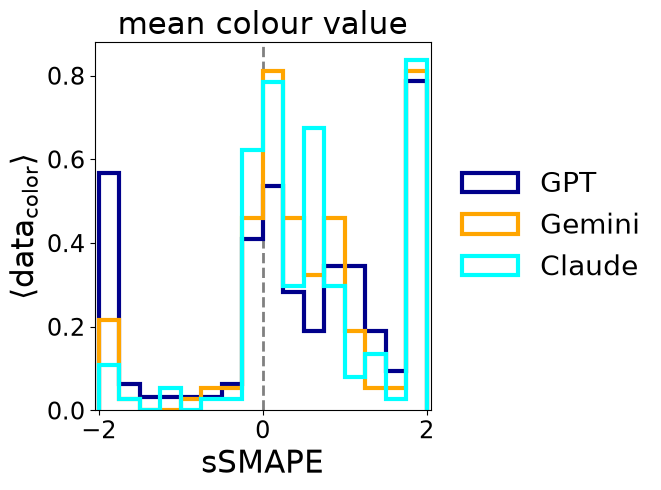

In [4]:
# ======================== PLOT ========================
fontsize       = 22
tick_fontsize  = 17
legend_fontsize = 20
base = 5

bins = np.linspace(-2, 2, nbins)

fig, ax = plt.subplots(figsize=(1.35 * base, base))

for mdir, (mname, color) in model_spec.items():
    vals = dfmean.loc[dfmean['model'] == mname, 'sSMAPE'].values
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        continue
    ax.hist(vals, bins=bins, density=True, label=mname,
            color=color, edgecolor=color, linewidth=hist_thick, histtype='step')

if show_zero_line:
    ax.axvline(0.0, color='gray', linestyle='--', linewidth=2, zorder=0)

ax.set_xlabel('sSMAPE', fontsize=fontsize)
ax.set_ylabel(question_label, fontsize=fontsize)
ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

ttl = 'mean colour value'
if only_category is not None:
    ttl += '  (%s)' % only_category
ax.set_title(ttl, fontsize=fontsize)

# legend outside on the right, as the paper figure does, so it never sits on
# top of a bar.  Anchored to the AXES, not the figure: a figure-level anchor
# fights bbox_inches='tight' and ends up back inside the plot.
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=legend_fontsize, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(fig_out_dir, fig_name), bbox_inches='tight')
print('wrote', os.path.join(fig_out_dir, fig_name))
